# Notebook 03: Lake Mead Wildfire Clustering

**Obstacle-aware k-means on a long, narrow lake**

Notebook 02 found that obstacle-aware k-means tightens the arc-length span by about 8% on the Lake Tahoe basin, but brings no improvement near the shore. The likely reason was Tahoe's compact, roughly oval shape: when a lake is compact, a fire's position around the shoreline is largely implied by its $(x, y)$ location, so the arc-length parameter $s$ adds little.

This notebook runs the same method on Lake Mead, which has a very different shape: long and narrow, with several major arms (Boulder Basin, the main eastern body, the Overton Arm to the north, and the channel south toward Hoover Dam). If the value of the obstacle parameter depends on obstacle shape, Mead should respond differently.

As in Tahoe, we compare three clusterings (standard k-means, obstacle-aware at equal weights, and obstacle-aware with $\beta$ tuned) on spatial features, at two scales:

- **Basin scale**: all 844 wildfires within a bounding box around Lake Mead.
- **Near-shore scale**: the 214 fires within 5 km of the shoreline.

The notebook ends with a brief look at cluster attribute composition, a comparison with Tahoe's findings, and saves the data the Notebook 04 dashboard uses.


## 1. Setup

In [44]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

#Suppress undecessary warnings
import warnings
from scipy.integrate import IntegrationWarning
warnings.filterwarnings('ignore', category=IntegrationWarning)
warnings.filterwarnings('ignore', message='.*Intel OpenMP.*')
warnings.filterwarnings('ignore', category=RuntimeWarning, module='threadpoolctl')

# Standard packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from IPython.display import display

#For querying USGS Hydrography dataset
import requests

# Database access for the FPA FOD wildfire data
import sqlite3

# Caching utilities so expensive cells only run once
import pickle
from pathlib import Path

# For polygon operations 
from shapely.geometry import Polygon as ShapelyPolygon
from shapely.ops import unary_union

# sklearn baseline and feature scaling
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Our custom package
from obstacle_clustering import SplineBoundary, ObstacleKMeans, attribute_separation

# --- Plot style ---
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 13,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
})

# Consistent cluster colors across all plots
CLUSTER_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# --- Caching ---
cache_dir = Path('../data/cached')
cache_dir.mkdir(parents=True, exist_ok=True)


def cached_or_run(cache_path, compute_fn, force_rerun=False):
    """Load from cache if it exists, otherwise run compute_fn and save."""
    cache_path = Path(cache_path)
    if cache_path.exists() and not force_rerun:
        print(f'Loading cached: {cache_path.name}')
        with open(cache_path, 'rb') as f:
            return pickle.load(f)
    print(f'Computing (will cache to {cache_path.name})...')
    result = compute_fn()
    with open(cache_path, 'wb') as f:
        pickle.dump(result, f)
    return result

# --- Helpers ---
def arc_length_span(s_values):
    """Arc-length span of a cluster on the loop [0, 1]."""
    if len(s_values) <= 1:
        return 0.0
    sorted_s = np.sort(s_values)
    gaps = np.diff(sorted_s)
    wrap_gap = (1.0 - sorted_s[-1]) + sorted_s[0]
    largest_gap = max(gaps.max(), wrap_gap)
    return 1.0 - largest_gap


def map_labels_to_reference(labels, reference_labels, k):
    """Greedy overlap-based label alignment for consistent cluster colors."""
    overlap = np.zeros((k, k), dtype=int)
    for i in range(k):
        for j in range(k):
            overlap[i, j] = np.sum((labels == i) & (reference_labels == j))

    mapping = {}
    used = set()
    sort_order = np.argsort(-overlap.max(axis=1))
    for i in sort_order:
        for j in np.argsort(-overlap[i]):
            if j not in used:
                mapping[i] = j
                used.add(j)
                break
    return mapping

## 2. Querying the USGS National Hydrography Dataset for Lake Mead

Lake Mead is a reservoir, so it doesn't appear in the NHD's Small-Scale Waterbody layer (layer 10) that we used for Tahoe. We query layer 12 (Waterbody - Large Scale, 1:24,000 resolution), which contains reservoirs.

In [2]:
NHD_WATERBODY_URL = (
    "https://hydro.nationalmap.gov/arcgis/rest/services/nhd/MapServer/12/query"
)

params = {
    'where': "GNIS_NAME = 'Lake Mead'",
    'outFields': 'GNIS_NAME,AREASQKM,ELEVATION,REACHCODE',
    'returnGeometry': 'true',
    'outSR': 4326,
    'f': 'json',
}

response = requests.get(NHD_WATERBODY_URL, params=params)
response.raise_for_status()
data = response.json()

n_features = len(data['features'])
print(f'Features returned: {n_features}')

for feat in data['features']:
    attrs = feat['attributes']
    print(f"  Name: {attrs['GNIS_NAME']}, "
          f"Area: {attrs['AREASQKM']:.1f} sq km, "
          f"Reach: {attrs['REACHCODE']}")

Features returned: 5
  Name: Lake Mead, Area: 0.0 sq km, Reach: 01100006001704
  Name: Lake Mead, Area: 541.3 sq km, Reach: 15010005009521
  Name: Lake Mead, Area: 0.1 sq km, Reach: 10090206001013
  Name: Lake Mead, Area: 0.7 sq km, Reach: 15010014003280
  Name: Lake Mead, Area: 7.2 sq km, Reach: 15010006010760


### Extracting Boundary Coordinates


The query returns multiple features named "Lake Mead." Most are tiny disconnected polygons (under 1 sq km), but two are real parts of the reservoir: the 541 sq km main body and a 7.2 sq km arm to the east that NHD stores separately. We union the features above 1 sq km so the boundary includes both and then extract the boundary coordinates.

In [3]:
# NHD splits Lake Mead across multiple HUC8 boundaries. Union all the
# features above 1 sq km to get the full lake 
polygons = [
    ShapelyPolygon(max(f['geometry']['rings'], key=len))
    for f in data['features']
    if f['attributes']['AREASQKM'] > 1.0
]
print(f'Unioning {len(polygons)} NHD polygons...')

unified = unary_union(polygons)
coords = np.array(unified.exterior.coords)

lon = coords[:, 0]
lat = coords[:, 1]

print(f'Exterior ring: {len(lon)} vertices')
print(f'Longitude range: [{lon.min():.4f}, {lon.max():.4f}]')
print(f'Latitude range:  [{lat.min():.4f}, {lat.max():.4f}]')

Unioning 2 NHD polygons...
Exterior ring: 74403 vertices
Longitude range: [-114.8748, -113.7790]
Latitude range:  [35.9945, 36.5378]


## 3. Cleaning the Boundary

Lake Mead's raw NHD polygon has ~74,000 vertices (compared to Tahoe's ~1,500) because the lake's complex shoreline is sampled finely at the 1:24,000 resolution. We simplify with a tolerance of 0.005 degrees (~450 m at this latitude), which reduces vertex count to a few hundred while preserving the major arms.

Vertices before simplification: 74403
Vertices after simplification:  418


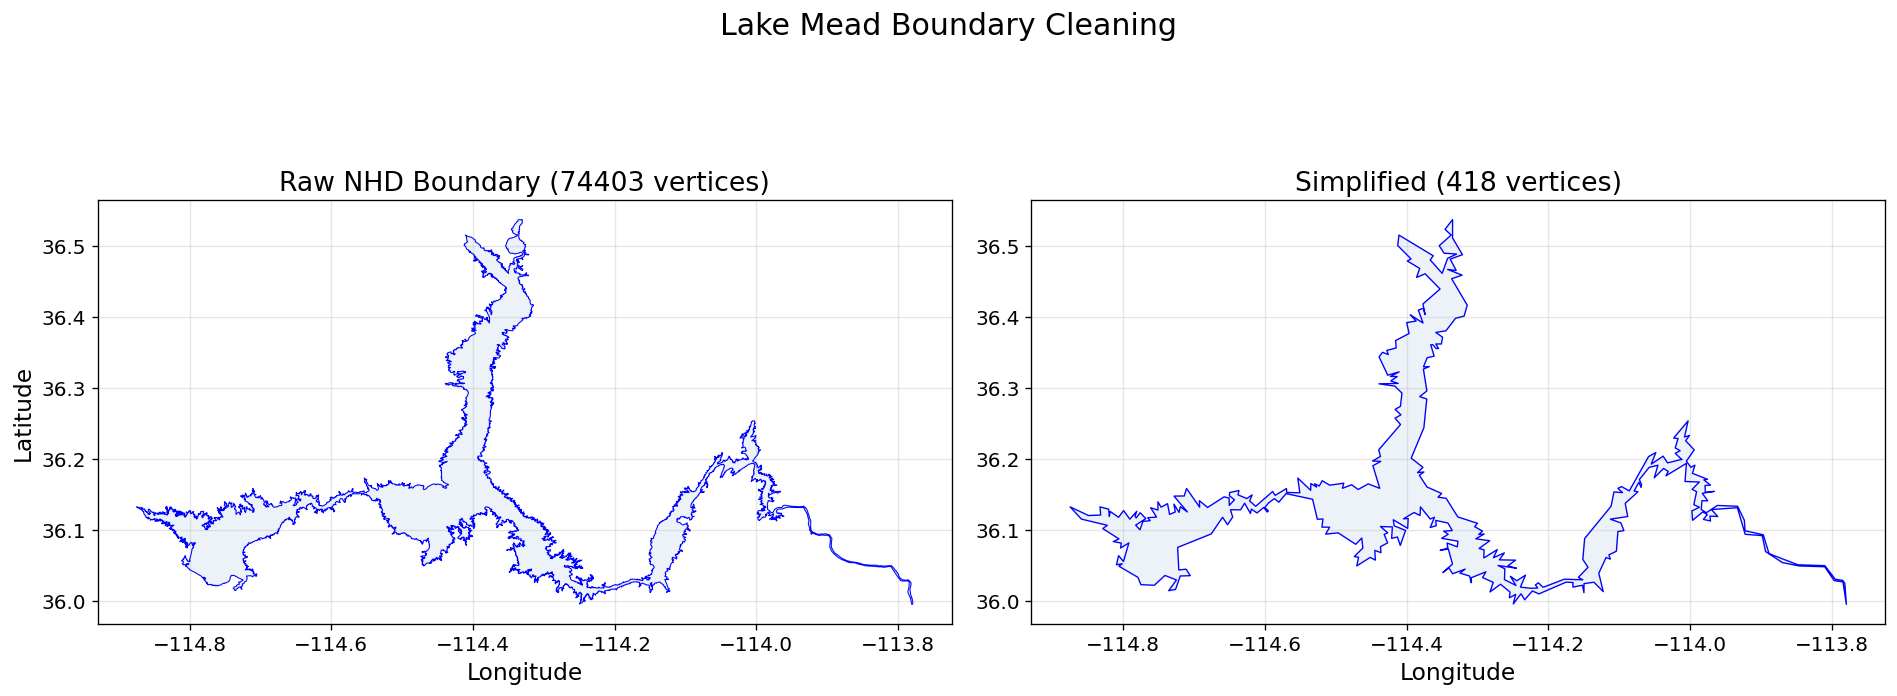


Using simplified boundary downstream (418 vertices).


In [4]:
raw_polygon = ShapelyPolygon(list(zip(lon, lat)))

tolerance = 0.005  # ~450 m at this latitude
simplified = raw_polygon.simplify(tolerance, preserve_topology=True)

simple_coords = np.array(simplified.exterior.coords)
lon_simple = simple_coords[:, 0]
lat_simple = simple_coords[:, 1]

print(f'Vertices before simplification: {len(lon)}')
print(f'Vertices after simplification:  {len(lon_simple)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(lon, lat, 'b-', linewidth=0.6)
ax.fill(lon, lat, alpha=0.1, color='steelblue')
ax.set_title(f'Raw NHD Boundary ({len(lon)} vertices)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(lon_simple, lat_simple, 'b-', linewidth=0.8)
ax.fill(lon_simple, lat_simple, alpha=0.1, color='steelblue')
ax.set_title(f'Simplified ({len(lon_simple)} vertices)')
ax.set_xlabel('Longitude')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.suptitle('Lake Mead Boundary Cleaning', y=1.02)
plt.tight_layout()
plt.show()

lon = lon_simple
lat = lat_simple
print(f'\nUsing simplified boundary downstream ({len(lon)} vertices).')

### Saving Boundary Coordinates

In [5]:
boundary_dir = Path('../data/boundaries')
boundary_dir.mkdir(parents=True, exist_ok=True)
boundary_path = boundary_dir / 'mead_boundary.csv'

boundary_df = pd.DataFrame({'longitude': lon, 'latitude': lat})
boundary_df.to_csv(boundary_path, index=False)

print(f'Saved {len(boundary_df)} boundary points to {boundary_path}')

Saved 418 boundary points to ..\data\boundaries\mead_boundary.csv


## 4. Fitting the Spline Boundary

Same approach as Tahoe: fit a closed cubic spline through the boundary vertices, parameterized by $t \in [0, 1]$, to get a smooth shoreline we can project fires onto. Mead's multi-arm shape makes this a more complex fit than Tahoe's, so it is especially important to verify the spine closely follows the whole shape below.

Total arc length: 6.8697 degrees
Parameter range: (0.0, 1.0)
Start matches end (closed loop): True


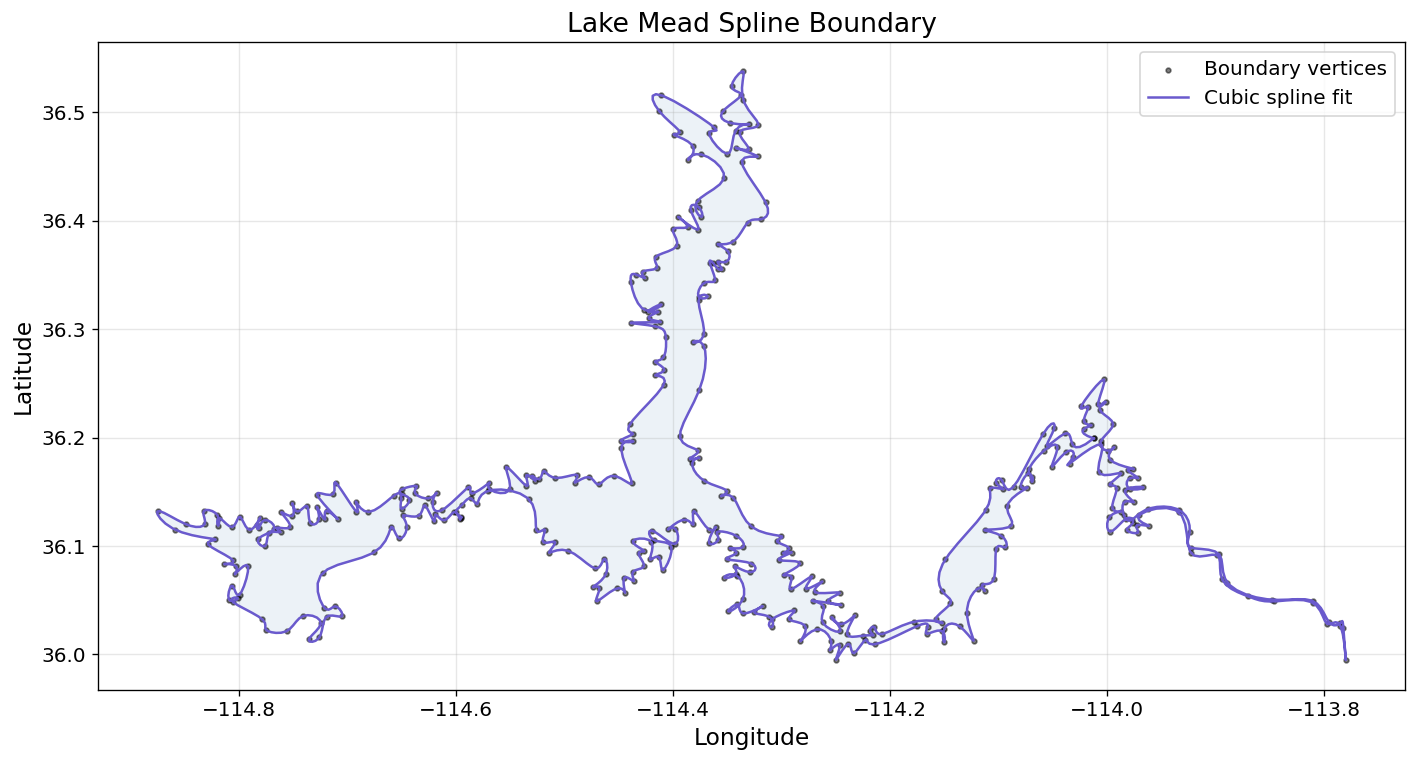

In [6]:
boundary = SplineBoundary(x_coords=lon, y_coords=lat)

L = boundary.total_arc_length()
print(f'Total arc length: {L:.4f} degrees')
print(f'Parameter range: {boundary.t_range()}')

# Verify start and end match (closed loop)
start_pt = boundary.evaluate(0.0)
end_pt = boundary.evaluate(1.0)
print(f'Start matches end (closed loop): {np.allclose(start_pt, end_pt, atol=1e-3)}')

# Sample the spline for visualization
spline_pts = boundary.sample_boundary(n_points=2000)

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(lon, lat, c='black', s=8, alpha=0.5, zorder=2,
           label='Boundary vertices')
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='slateblue', linewidth=1.5,
        zorder=3, label='Cubic spline fit')
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Lake Mead Spline Boundary')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Loading Wildfire Data

We pull fires from FPA FOD within a bounding box around Lake Mead. Unlike the Tahoe analysis, there's no official basin polygon to clip to -- the Lake Mead National Recreation Area covers a much larger area including Lake Mohave downstream. We just use the bounding box, which captures fires within roughly 20 km of any part of the lake.

In [7]:
# Bounding box around Lake Mead
LAT_MIN, LAT_MAX = 35.8, 36.6
LON_MIN, LON_MAX = -115.0, -113.7

db_path = '../data/raw/fires.sqlite'

query = """
    SELECT LATITUDE, LONGITUDE, FIRE_SIZE, NWCG_GENERAL_CAUSE,
           NWCG_CAUSE_CLASSIFICATION, FIRE_YEAR, DISCOVERY_DOY
    FROM Fires
    WHERE LATITUDE BETWEEN ? AND ?
      AND LONGITUDE BETWEEN ? AND ?
"""

with sqlite3.connect(db_path) as conn:
    fires_raw = pd.read_sql_query(
        query, conn,
        params=(LAT_MIN, LAT_MAX, LON_MIN, LON_MAX),
    )

print(f'Fires in SQL bounding box: {len(fires_raw)}')
print(f'Year range: {fires_raw["FIRE_YEAR"].min()}-{fires_raw["FIRE_YEAR"].max()}')
print(f'\nCause breakdown:')
print(fires_raw['NWCG_GENERAL_CAUSE'].value_counts().to_string())

Fires in SQL bounding box: 1059
Year range: 1992-2020

Cause breakdown:
NWCG_GENERAL_CAUSE
Natural                                       493
Missing data/not specified/undetermined       215
Equipment and vehicle use                     102
Recreation and ceremony                        64
Debris and open burning                        45
Fireworks                                      36
Arson/incendiarism                             35
Smoking                                        31
Firearms and explosives use                    21
Misuse of fire by a minor                      10
Other causes                                    4
Power generation/transmission/distribution      2
Railroad operations and maintenance             1


## 6. Cleaning and Feature Engineering

Same steps as Tahoe: drop missing-cause fires, binary-encode cause, log-transform fire size.

In [8]:
# --- Step 1: Drop missing-cause fires ---
fires = fires_raw[
    fires_raw['NWCG_GENERAL_CAUSE'] != 'Missing data/not specified/undetermined'
].copy().reset_index(drop=True)
print(f'Fires after filtering missing cause: {len(fires)}')

# --- Step 2: Encode cause as binary (0 = Natural, 1 = Human-caused) ---
# Safe because missing/undetermined rows were already dropped above.
fires['cause_binary'] = (fires['NWCG_GENERAL_CAUSE'] != 'Natural').astype(int)

# --- Step 3: Log-transform fire size (heavy right tail) ---
fires['fire_size_log'] = np.log1p(fires['FIRE_SIZE'].values)

print(f'\nCause classification:')
print(f"  Natural (lightning): {(fires['cause_binary'] == 0).sum()}")
print(f"  Human-caused:        {(fires['cause_binary'] == 1).sum()}")

print(f'\nFire size (acres):')
print(f"  Min:    {fires['FIRE_SIZE'].min():.4f}")
print(f"  Median: {fires['FIRE_SIZE'].median():.2f}")
print(f"  Mean:   {fires['FIRE_SIZE'].mean():.2f}")
print(f"  Max:    {fires['FIRE_SIZE'].max():.2f}")

Fires after filtering missing cause: 844

Cause classification:
  Natural (lightning): 493
  Human-caused:        351

Fire size (acres):
  Min:    0.1000
  Median: 0.10
  Mean:   484.55
  Max:    44707.00


## 7. Projecting Fires onto the Lake Boundary

For each fire we find the closest point on the boundary spline, recording its spline parameter $t$ and arc-length position $s$. As with Tahoe, this can take a few minutes, so the result is cached.

In [9]:
def project_all_fires():
    print('Projecting fire locations onto lake boundary...')
    lons = fires['LONGITUDE'].values
    lats = fires['LATITUDE'].values
    n = len(fires)

    t_arr = np.zeros(n)
    s_arr = np.zeros(n)
    for idx in range(n):
        if idx % 200 == 0:
            print(f'  {idx}/{n} ({100*idx/n:.0f}%)')
        t_arr[idx], s_arr[idx] = boundary.project_point(lons[idx], lats[idx])
    return t_arr, s_arr


t_values, s_values = cached_or_run(
    cache_dir / 'mead_fire_projections.pkl',
    project_all_fires,
)

fires['t_param'] = t_values
fires['s_param'] = s_values

print(f'Projection complete: {len(fires)} fires projected')
print(f's range: [{fires["s_param"].min():.4f}, {fires["s_param"].max():.4f}]')

Loading cached: mead_fire_projections.pkl
Projection complete: 844 fires projected
s range: [0.0109, 0.9882]


### Visualizing the Raw Data

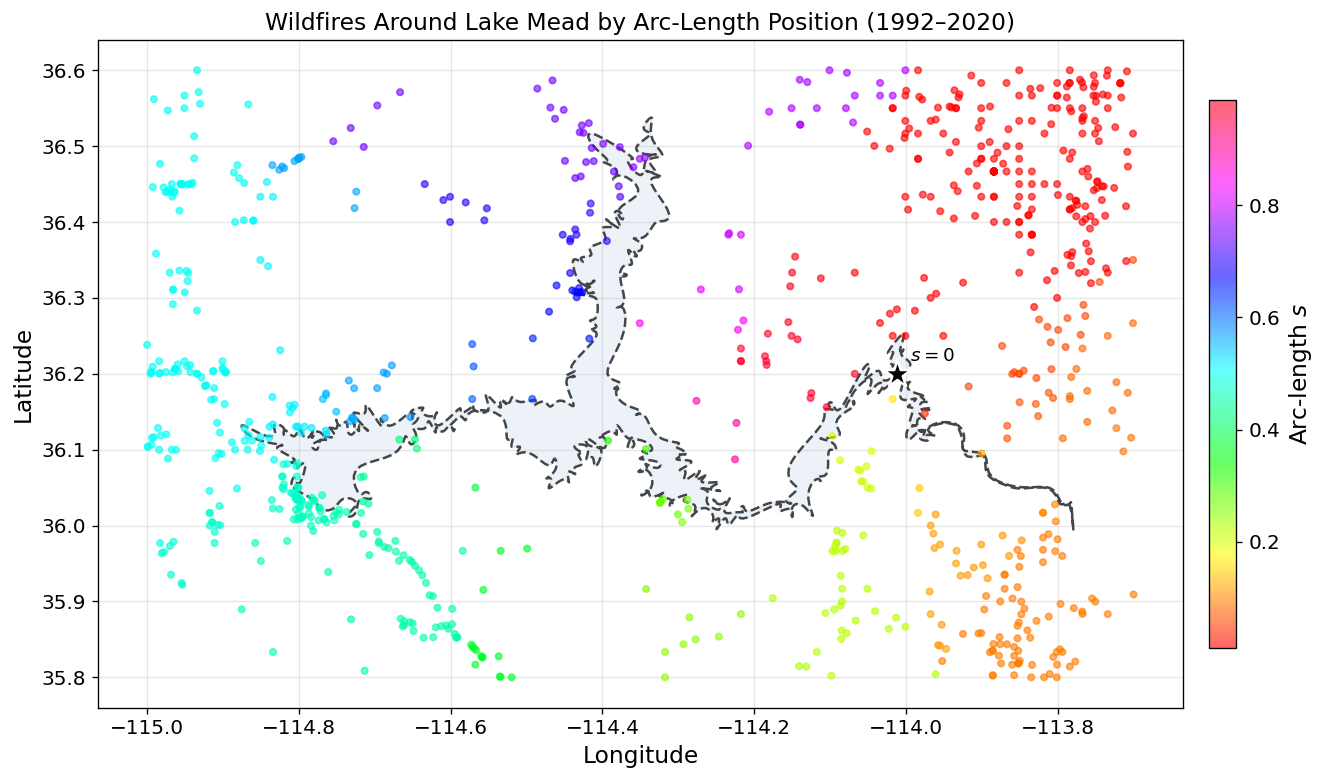

In [10]:
fig, ax = plt.subplots(figsize=(12, 8))

# Boundary
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

# Fires colored by arc-length position. HSV wraps, so s=0 and s=1 share a color.
scatter = ax.scatter(fires['LONGITUDE'], fires['LATITUDE'],
                     c=fires['s_param'], cmap='hsv', s=15, alpha=0.6, zorder=3)
plt.colorbar(scatter, ax=ax, label='Arc-length $s$', shrink=0.6, aspect=20, pad=0.02)

# Mark the boundary's start position (s = 0)
s0_xy = boundary.evaluate(boundary.t_range()[0])
ax.scatter(s0_xy[0], s0_xy[1], marker='*', s=300, color='black',
           edgecolors='white', linewidth=1.5, zorder=5)
ax.annotate('$s = 0$', xy=(s0_xy[0], s0_xy[1]), xytext=(8, 8),
            textcoords='offset points', fontsize=11, fontweight='bold')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

year_min = fires['FIRE_YEAR'].min()
year_max = fires['FIRE_YEAR'].max()
ax.set_title(f'Wildfires Around Lake Mead by Arc-Length Position '
             f'({year_min}\u2013{year_max})', fontsize=14)

plt.tight_layout()
plt.show()

## 8. Feature Matrix

Same structure as Tahoe: scaled XY in columns 0-1, $s$ in column 2, scaled log fire size in column 3, cause binary in column 4. The clustering uses only the spatial columns (0-2); fire size and cause are kept for the attribute section later.

In [11]:
scaler_xy = MinMaxScaler()
xy_scaled = scaler_xy.fit_transform(fires[['LONGITUDE', 'LATITUDE']].values)

scaler_size = MinMaxScaler()
fire_size_scaled = scaler_size.fit_transform(fires[['fire_size_log']].values)

X = np.column_stack([
    xy_scaled,
    fires['s_param'].values,
    fire_size_scaled.ravel(),
    fires['cause_binary'].values
])

feature_names = ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']
print(f'Feature matrix shape: {X.shape}')

Feature matrix shape: (844, 5)


## 9. Basin-Scale Clustering: Standard k-means Baseline

The baseline is plain k-means on scaled $(x, y)$. We record its mean arc-length span; every obstacle-aware variant is measured against this number.

We use $k = 4$, the same as the Lake Tahoe analysis. Holding the number of clusters fixed across both lakes keeps the comparison controlled, so any difference in how the obstacle parameter behaves reflects the lakes' geometry rather than a different cluster count.

In [12]:
k = 4 # held fixed across both lakes for a controlled comparison

kmeans_basin = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_basin_std = kmeans_basin.fit_predict(X[:, :2])

spans_basin_std = [
    arc_length_span(fires['s_param'].values[labels_basin_std == c])
    for c in range(k)
]

print(f'Standard k-means converged in {kmeans_basin.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_basin_std == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_basin_std):.4f}')
print(f'\nSee clusters plotted in Section 12')

Standard k-means converged in 7 iterations

Cluster sizes:
  Cluster 1: 185 fires
  Cluster 2: 124 fires
  Cluster 3: 273 fires
  Cluster 4: 262 fires

Mean arc-length span: 0.3412

See clusters plotted in Section 12


## 10. Basin-Scale Clustering: Obstacle-Aware k-means at Equal Weights

The same obstacle-aware method as Tahoe, with distance

$$d^2(\mathbf{x}, \mathbf{x}') = \alpha^2 \, \lVert \text{geo} - \text{geo}' \rVert^2 + \beta^2 \, d_s(s, s')^2$$

combining straight-line distance with shoreline distance $d_s$ (the shorter way around the loop). We hold $\alpha = 1$ and start at equal weights, $\beta = 1$.

In [13]:
model_basin_eq = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=0.0,
    random_state=42, n_attr=0
)
model_basin_eq.fit(X[:, :3], t_data=fires['t_param'].values)
labels_basin_eq = model_basin_eq.labels_

spans_basin_eq = [
    arc_length_span(fires['s_param'].values[labels_basin_eq == c])
    for c in range(k)
]

print(f'OA equal weights: converged in {model_basin_eq.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_basin_eq == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_basin_eq):.4f}')
print(f'\nSee clusters plotted in Section 12')

OA equal weights: converged in 9 iterations

Cluster sizes:
  Cluster 1: 274 fires
  Cluster 2: 262 fires
  Cluster 3: 124 fires
  Cluster 4: 184 fires

Mean arc-length span: 0.3412

See clusters plotted in Section 12


## 11. Basin-Scale Clustering: Obstacle-Aware k-means at Optimized $\beta$

Same workflow as Tahoe: sweep $\beta$, record $J$ and the mean span at each, plot the two together, then select $\beta$.

In [14]:
def compute_mead_basin_beta_sweep():
    """Sweep beta, recording J (within-cluster distortion) and mean span at each.

    One model fit per beta gives both metrics, so J and span always come from
    the same clustering rather than two separate fits.
    """
    print('Computing Mead basin beta sweep (J and span)...')
    n_grid = 30
    beta_vals = np.linspace(0.05, 2.0, n_grid)
    J_vals = np.zeros(n_grid)
    span_vals = np.zeros(n_grid)

    for i, b in enumerate(beta_vals):
        model_b = ObstacleKMeans(
            k=k, boundary=boundary,
            alpha=1.0, beta=b, gamma=0.0,
            random_state=42, n_attr=0
        )
        model_b.fit(X[:, :3], t_data=fires['t_param'].values)

        # J is the model's mean within-cluster distortion (rho_bar), with no
        # beta applied, so J is comparable across beta.
        J_vals[i] = model_b.rho_bar_

        # Mean arc-length span from the same fit
        spans_b = [
            arc_length_span(fires['s_param'].values[model_b.labels_ == c])
            for c in range(k)
        ]
        span_vals[i] = np.mean(spans_b)

    return beta_vals, J_vals, span_vals


beta_grid_basin, J_vals_basin, spans_by_beta_basin = cached_or_run(
    cache_dir / 'mead_basin_beta_sweep.pkl',
    compute_mead_basin_beta_sweep,
)

# Where J is lowest on the grid, for reference (not necessarily our final pick)
i_min_basin = J_vals_basin.argmin()
j_min_beta_basin = beta_grid_basin[i_min_basin]
j_min_J_basin = J_vals_basin[i_min_basin]

print(f'J-minimum on grid: beta = {j_min_beta_basin:.4f}, J = {j_min_J_basin:.4f}')

Loading cached: mead_basin_beta_sweep.pkl
J-minimum on grid: beta = 1.5293, J = 0.0407


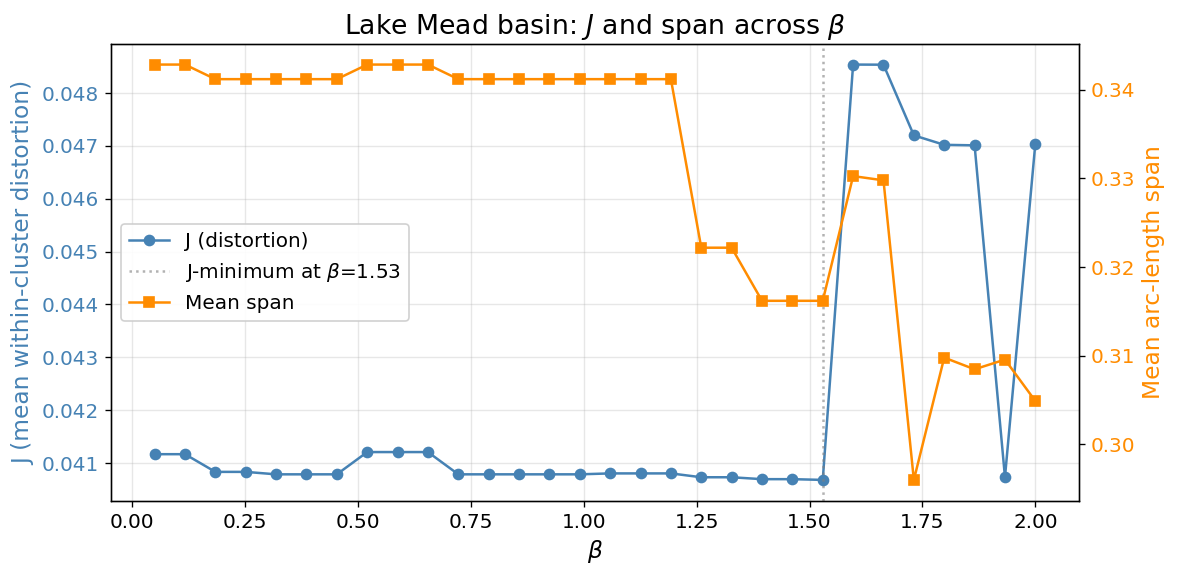

In [15]:
# Plot the J / span over the 30 beta grid points
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: objective J (within-cluster distortion)
color_J = 'steelblue'
ax1.plot(beta_grid_basin, J_vals_basin, 'o-', color=color_J, label='J (distortion)')
ax1.set_xlabel(r'$\beta$')
ax1.set_ylabel('J (mean within-cluster distortion)', color=color_J)
ax1.tick_params(axis='y', labelcolor=color_J)

# Right axis: mean arc-length span
ax2 = ax1.twinx()
color_span = 'darkorange'
ax2.plot(beta_grid_basin, spans_by_beta_basin, 's-', color=color_span,
         label='Mean span')
ax2.set_ylabel('Mean arc-length span', color=color_span)
ax2.tick_params(axis='y', labelcolor=color_span)

# Mark the J-minimum for reference
ax1.axvline(j_min_beta_basin, color='gray', linestyle=':', alpha=0.6,
            label=rf'J-minimum at $\beta$={j_min_beta_basin:.2f}')

ax1.set_title(r'Lake Mead basin: $J$ and span across $\beta$')
ax1.grid(True, alpha=0.3)

# Combine legends from both axes, placed center-left and drawn on top
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
leg = ax2.legend(lines1 + lines2, labels1 + labels2, loc='center left')
leg.set_zorder(10)
leg.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.show()

### Selecting $\beta$ and Refitting

$J$ is nearly flat across a wide range, and within that region the span is flat too, so a range of $\beta$ values tie for the lowest span. As in the Lake Tahoe notebook, we restrict to $\beta$ values whose $J$ is within tolerance of the minimum and that sit in a stable low-$J$ stretch, requiring every cluster to hold more than 10 fires, then take the smallest span among those. This lands at the grid minimum, $\beta = 1.53$. There's a slightly lower span past the flat region (near $\beta = 1.9$), but it sits at an isolated low-$J$ point surrounded by high-$J$ neighbors, so the stability filter excludes it.

In [16]:
# Same robust selection as the other runs: stable low-J region, smallest span,
# every cluster above the size floor. We check stable candidates for in span order and stop at the
# first that passes.
J_tol = 0.001
min_cluster_size = 10

J_best = J_vals_basin.min()
low_J = J_vals_basin <= J_best + J_tol

left_ok = np.zeros_like(low_J)
right_ok = np.zeros_like(low_J)
left_ok[1:] = low_J[:-1]
right_ok[:-1] = low_J[1:]
stable = low_J & (left_ok | right_ok)

candidates = np.where(stable)[0]
candidates = candidates[np.argsort(spans_by_beta_basin[candidates])]

opt_beta_basin = None
for idx in candidates:
    b = beta_grid_basin[idx]
    m = ObstacleKMeans(k=k, boundary=boundary, alpha=1.0, beta=b, gamma=0.0,
                       random_state=42, n_attr=0)
    m.fit(X[:, :3], t_data=fires['t_param'].values)
    sizes = [np.sum(m.labels_ == c) for c in range(k)]
    if min(sizes) > min_cluster_size:
        opt_beta_basin = b
        i_sel = idx
        break

if opt_beta_basin is None:
    raise ValueError('No stable low-J beta satisfies the size floor; loosen J_tol.')

print(f'Selected beta = {opt_beta_basin:.4f} '
      f'(J = {J_vals_basin[i_sel]:.4f}, span = {spans_by_beta_basin[i_sel]:.4f})')

Selected beta = 1.5293 (J = 0.0407, span = 0.3162)


In [17]:
# Refit at the selected beta
model_basin_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=opt_beta_basin, gamma=0.0,
    random_state=42, n_attr=0
)
model_basin_opt.fit(X[:, :3], t_data=fires['t_param'].values)
labels_basin_opt = model_basin_opt.labels_

spans_basin_opt = [
    arc_length_span(fires['s_param'].values[labels_basin_opt == c])
    for c in range(k)
]

print(f'Optimized beta: {opt_beta_basin:.4f}')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_basin_opt == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_basin_opt):.4f}')

Optimized beta: 1.5293

Cluster sizes:
  Cluster 1: 276 fires
  Cluster 2: 183 fires
  Cluster 3: 124 fires
  Cluster 4: 261 fires

Mean arc-length span: 0.3162


## 12. Basin Clustering Method Comparison

We compare the results of our three clustering methods on the basin-wide subset.

### Aligning Cluster Labels
Because k-means assigns cluster IDs arbitrarily, we relabel the obstacle-aware clusters to share IDs and colors with the standard baseline. This is a visual aid only; it doesn't change the clustering.

In [18]:
# Standard k-means is the reference labeling for the basin
labels_basin_std_aligned = labels_basin_std

eq_to_std_basin = map_labels_to_reference(labels_basin_eq, labels_basin_std, k)
labels_basin_eq_aligned = np.array(
    [eq_to_std_basin[l] for l in labels_basin_eq]
)

opt_to_std_basin = map_labels_to_reference(labels_basin_opt, labels_basin_std, k)
labels_basin_opt_aligned = np.array(
    [opt_to_std_basin[l] for l in labels_basin_opt]
)

print('Labels aligned: equal-weight and optimized clusters now share IDs')
print('with the standard k-means baseline.')

Labels aligned: equal-weight and optimized clusters now share IDs
with the standard k-means baseline.


### Visual Comparison

Across the three panels the broad layout is stable: four clusters split roughly by region, with orange along the southwest shore, blue to the northwest, green to the northeast, and red to the southeast. Standard k-means and equal weights come out nearly identical here.

The optimized clustering shifts the boundaries slightly along the lake's arms. The clearest changes are around the central body and the southeastern arm, where some fires move between clusters.

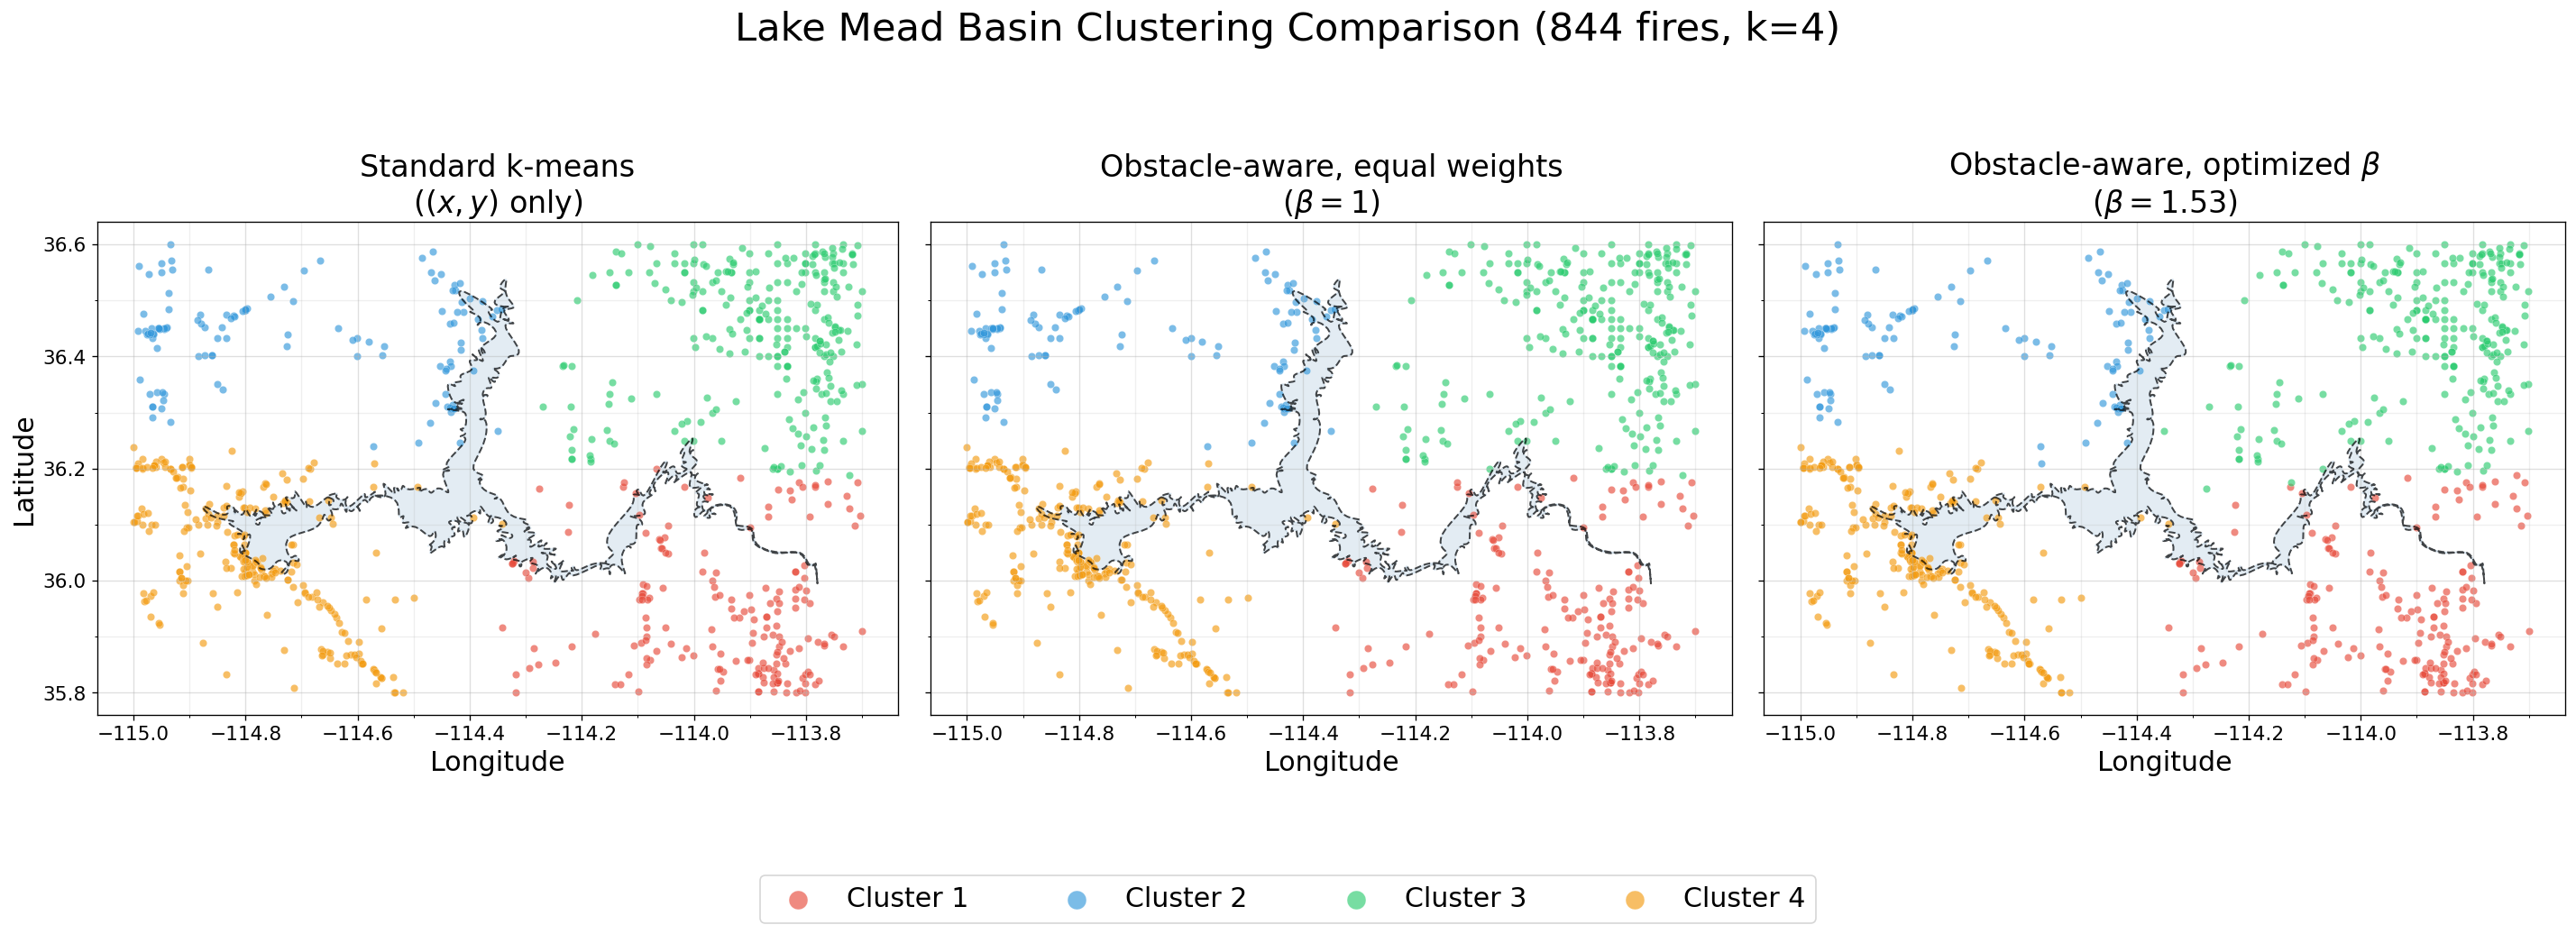

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharex=True, sharey=True)

for ax, labels, title in [
    (axes[0], labels_basin_std_aligned, 'Standard k-means\n($(x, y)$ only)'),
    (axes[1], labels_basin_eq_aligned,
     r'Obstacle-aware, equal weights' + '\n' + r'($\beta = 1$)'),
    (axes[2], labels_basin_opt_aligned,
     r'Obstacle-aware, optimized $\beta$' + '\n' +
     rf'($\beta = {opt_beta_basin:.2f}$)'),
]:
    # Boundary
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
            linewidth=1.2, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.15, color='steelblue')

    # Fires colored by cluster
    for i in range(k):
        mask = labels == i
        ax.scatter(fires['LONGITUDE'].values[mask],
                   fires['LATITUDE'].values[mask],
                   c=CLUSTER_COLORS[i], s=25, alpha=0.65,
                   label=f'Cluster {i+1}', edgecolors='white', linewidth=0.2)

    ax.set_title(title, fontsize=20)
    ax.set_xlabel('Longitude', fontsize=18)
    ax.set_aspect('equal')

    # Gridlines every 0.10 on both axes; labels only every 0.20
    ax.xaxis.set_major_locator(MultipleLocator(0.20))   # labeled
    ax.xaxis.set_minor_locator(MultipleLocator(0.10))   # gridline only
    ax.yaxis.set_major_locator(MultipleLocator(0.20))   # labeled
    ax.yaxis.set_minor_locator(MultipleLocator(0.10))   # gridline only
    ax.grid(which='major', alpha=0.4)
    ax.grid(which='minor', alpha=0.2)

    ax.tick_params(axis='both', which='major', labelsize=13)

axes[0].set_ylabel('Latitude', fontsize=18)

# Larger legend, pushed further below the panels
handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, leg_labels, loc='lower center', ncol=k,
           bbox_to_anchor=(0.5, -0.04), frameon=True, fontsize=18,
           markerscale=2.5, columnspacing=3.0, handletextpad=0.8)

fig.suptitle(f'Lake Mead Basin Clustering Comparison ({len(fires)} fires, k={k})',
             fontsize=26, y=1.03)

# Reserve bottom room for the legend; pull panels close together
plt.tight_layout(rect=[0, 0.10, 1, 0.97])
plt.subplots_adjust(wspace=0.04)
plt.show()

### Comparison Statistics

Equal weights produces exactly the same clustering as standard k-means (every per-cluster span matches), so on its own the obstacle parameter changes nothing at the basin scale. The improvement only appears once $\beta$ is tuned up: at $\beta = 1.53$ the mean span tightens by 7.3% over standard. The per-cluster columns show where it comes from: Clusters 1 and 2 tighten (Cluster 2 the most, from 0.34 to 0.27), while Clusters 3 and 4 are essentially unchanged. So the gain is concentrated in a couple of clusters rather than spread across all four.

In [37]:
# Recompute per-cluster spans from the aligned labels so the columns match
# the plot colors and are comparable across methods.
spans_basin_std_aligned = [arc_length_span(fires['s_param'].values[labels_basin_std_aligned == c]) for c in range(k)]
spans_basin_eq_aligned  = [arc_length_span(fires['s_param'].values[labels_basin_eq_aligned == c])  for c in range(k)]
spans_basin_opt_aligned = [arc_length_span(fires['s_param'].values[labels_basin_opt_aligned == c]) for c in range(k)]

basin_methods = [
    ('Standard k-means', spans_basin_std_aligned),
    ('OA, equal weights (β=1)', spans_basin_eq_aligned),
    (f'OA, optimized (β={opt_beta_basin:.2f})', spans_basin_opt_aligned),
]

std_mean_basin = np.mean(spans_basin_std_aligned)

rows = []
for name, spans in basin_methods:
    mean_span = np.mean(spans)
    # Percent change in span vs standard; negative span change = improvement,
    # so we report improvement as a positive percent (standard is the 0% baseline).
    pct = 100 * (std_mean_basin - mean_span) / std_mean_basin
    row = {'Method': name}
    for c in range(k):
        row[f'Cluster {c+1}'] = spans[c]
    row['Mean span'] = mean_span
    row['vs standard'] = pct
    rows.append(row)

basin_comparison = pd.DataFrame(rows).set_index('Method')

# Format: spans to 4 decimals, percent with sign and 1 decimal
fmt = {f'Cluster {c+1}': '{:.4f}' for c in range(k)}
fmt['Mean span'] = '{:.4f}'
fmt['vs standard'] = '{:+.1f}%'

print(f'Lake Mead basin cluster spans comparison ({len(fires)} fires)')
basin_comparison.style.format(fmt)

Lake Mead basin cluster spans comparison (844 fires)


,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Mean span,vs standard
Method,,,,,,
Standard k-means,0.3966,0.3414,0.3049,0.3220,0.3412,+0.0%
"OA, equal weights (β=1)",0.3966,0.3414,0.3049,0.3220,0.3412,+0.0%
"OA, optimized (β=1.53)",0.3726,0.2655,0.3047,0.3220,0.3162,+7.3%


## 13. Near-Shore Subset

Same approach as Tahoe, with a 5 km threshold instead of 1 km. We chose 5 km to keep a similar fraction of the data as Tahoe's 1 km cutoff: about 25% of fires here, close to Tahoe's 27%. This keeps the near-shore definition consistent between the two lakes rather than fixing an arbitrary distance.

In [21]:
# Each fire's straight-line distance to its boundary projection.
# At latitude ~36 N: 1 deg lat ~= 111 km, 1 deg lon ~= 90 km.
proj = np.array([boundary.evaluate(t) for t in fires['t_param'].values])
lon_diff = fires['LONGITUDE'].values - proj[:, 0]
lat_diff = fires['LATITUDE'].values - proj[:, 1]
fires['dist_to_lake_km'] = np.sqrt((lon_diff * 90)**2 + (lat_diff * 111)**2)

print('Fire distance distribution (km from Lake Mead shore):')
for thr in [1, 2, 5, 10]:
    n = (fires['dist_to_lake_km'] < thr).sum()
    print(f'  Within {thr:2d} km: {n:4d} fires ({100*n/len(fires):.1f}%)')

# 5 km threshold
threshold_km = 5
near_mask = fires['dist_to_lake_km'].values < threshold_km
n_near = int(near_mask.sum())

print(f'\nNear-shore subset: {n_near} fires within {threshold_km} km of shore')

X_near = X[near_mask]
t_near = fires['t_param'].values[near_mask]
s_near = fires['s_param'].values[near_mask]
fires_near = fires[near_mask].copy().reset_index(drop=True)

Fire distance distribution (km from Lake Mead shore):
  Within  1 km:   99 fires (11.7%)
  Within  2 km:  137 fires (16.2%)
  Within  5 km:  214 fires (25.4%)
  Within 10 km:  304 fires (36.0%)

Near-shore subset: 214 fires within 5 km of shore


## 14. Near-Shore Clustering: Three Methods

The same three methods as the basin, applied to the near-shore subset.

### 14.1 Standard k-means (Near-Shore)

In [22]:
kmeans_near = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_near_std = kmeans_near.fit_predict(X_near[:, :2])

spans_near_std = [arc_length_span(s_near[labels_near_std == c]) for c in range(k)]

print(f'Standard k-Means on near-shore subset:')
print(f'  Converged in {kmeans_near.n_iter_} iterations')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_near_std == i)} fires')
print(f'  Mean arc-length span: {np.mean(spans_near_std):.4f}')
print(f'\nSee clusters plotted in Section 15')

Standard k-Means on near-shore subset:
  Converged in 3 iterations
  Cluster 1: 126 fires
  Cluster 2: 16 fires
  Cluster 3: 40 fires
  Cluster 4: 32 fires
  Mean arc-length span: 0.2425

See clusters plotted in Section 15


### 14.2 Obstacle-Aware k-means at Equal Weights (Near-Shore)

In [23]:
model_near_eq = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=0.0,
    random_state=42, n_attr=0
)
model_near_eq.fit(X_near[:, :3], t_data=t_near)
labels_near_eq = model_near_eq.labels_

spans_near_eq = [arc_length_span(s_near[labels_near_eq == c]) for c in range(k)]

print(f'OA equal weights on near-shore subset:')
print(f'  Converged in {model_near_eq.n_iter_} iterations')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_near_eq == i)} fires')
print(f'  Mean arc-length span: {np.mean(spans_near_eq):.4f}')
print(f'\nSee clusters plotted in Section 15')

OA equal weights on near-shore subset:
  Converged in 8 iterations
  Cluster 1: 33 fires
  Cluster 2: 126 fires
  Cluster 3: 40 fires
  Cluster 4: 15 fires
  Mean arc-length span: 0.2204

See clusters plotted in Section 15


### 14.3 Obstacle-Aware k-means at Optimized $\beta$ (Near-Shore)
Same workflow as the basin: sweep $\beta$, record $J$ and the mean span at each, plot the two together, then select $\beta$.

In [24]:
def compute_mead_nearshore_beta_sweep():
    """Sweep beta, recording J (within-cluster distortion) and mean span at each.

    One model fit per beta gives both metrics, so J and span always come from
    the same clustering rather than two separate fits.
    """
    print('Computing Mead near-shore beta sweep (J and span)...')
    n_grid = 30
    beta_vals = np.linspace(0.05, 2.0, n_grid)
    J_vals = np.zeros(n_grid)
    span_vals = np.zeros(n_grid)

    for i, b in enumerate(beta_vals):
        model_b = ObstacleKMeans(
            k=k, boundary=boundary,
            alpha=1.0, beta=b, gamma=0.0,
            random_state=42, n_attr=0
        )
        model_b.fit(X_near[:, :3], t_data=t_near)

        # J is the model's mean within-cluster distortion (rho_bar), with no
        # beta applied, so J is comparable across beta.
        J_vals[i] = model_b.rho_bar_

        # Mean arc-length span from the same fit
        spans_b = [arc_length_span(s_near[model_b.labels_ == c]) for c in range(k)]
        span_vals[i] = np.mean(spans_b)

    return beta_vals, J_vals, span_vals


beta_grid_near, J_vals_near, spans_by_beta_near = cached_or_run(
    cache_dir / 'mead_nearshore_beta_sweep.pkl',
    compute_mead_nearshore_beta_sweep,
)

# Where J is lowest on the grid, for reference (not necessarily our final pick)
i_min_near = J_vals_near.argmin()
j_min_beta_near = beta_grid_near[i_min_near]
j_min_J_near = J_vals_near[i_min_near]

print(f'J-minimum on grid: beta = {j_min_beta_near:.4f}, J = {j_min_J_near:.4f}')

Loading cached: mead_nearshore_beta_sweep.pkl
J-minimum on grid: beta = 0.5879, J = 0.0155


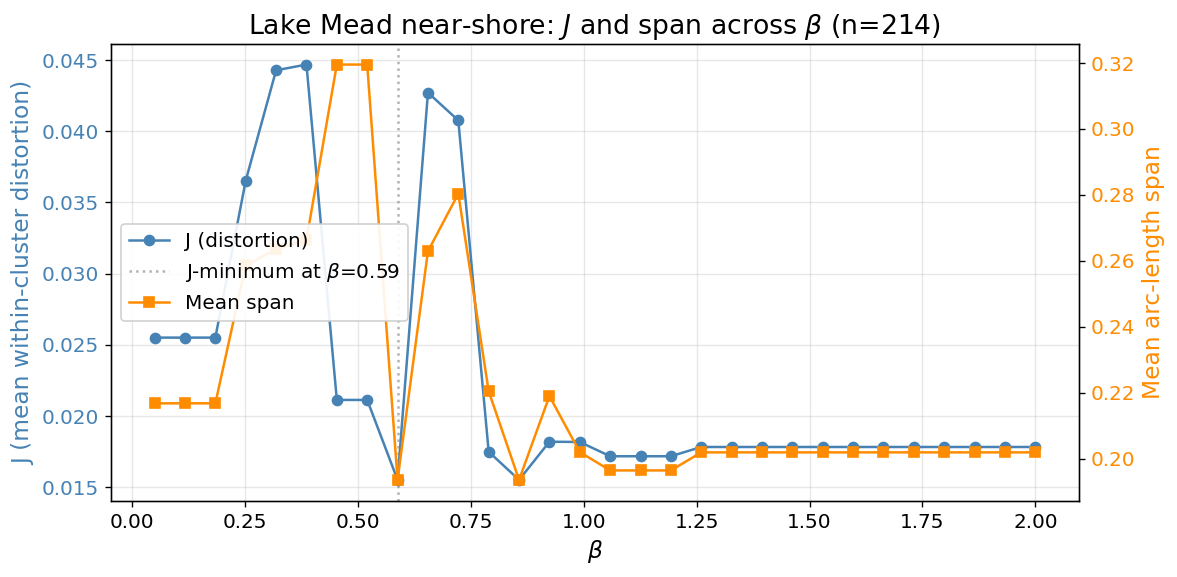

In [25]:
# Plot the J / span over the 30 beta grid points
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: objective J (within-cluster distortion)
color_J = 'steelblue'
ax1.plot(beta_grid_near, J_vals_near, 'o-', color=color_J, label='J (distortion)')
ax1.set_xlabel(r'$\beta$')
ax1.set_ylabel('J (mean within-cluster distortion)', color=color_J)
ax1.tick_params(axis='y', labelcolor=color_J)

# Right axis: mean arc-length span
ax2 = ax1.twinx()
color_span = 'darkorange'
ax2.plot(beta_grid_near, spans_by_beta_near, 's-', color=color_span,
         label='Mean span')
ax2.set_ylabel('Mean arc-length span', color=color_span)
ax2.tick_params(axis='y', labelcolor=color_span)

# Mark the J-minimum for reference
ax1.axvline(j_min_beta_near, color='gray', linestyle=':', alpha=0.6,
            label=rf'J-minimum at $\beta$={j_min_beta_near:.2f}')

ax1.set_title(rf'Lake Mead near-shore: $J$ and span across $\beta$ (n={n_near})')
ax1.grid(True, alpha=0.3)

# Combine legends from both axes, placed center-left and drawn on top
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
leg = ax2.legend(lines1 + lines2, labels1 + labels2, loc='center left')
leg.set_zorder(10)
leg.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.show()

### Selecting $\beta$ and Refitting
The grid minimum is at $\beta = 0.59$, but the plot reveals this may not be the best choice. $J$ drops to a sharp point there and jumps right back up at the neighbors on either side, so the clustering at $\beta = 0.59$ only holds at that exact weighting.

We apply the same selection as the basin run. The difference here is that the size constraint actually matters: the lowest-span betas are exactly the ones that collapse a cluster onto a handful of fires, so the constraint is what pushes the choice into the stable region past $\beta = 1.0$. The selection lands at $\beta = 1.19$, where $J$ and span are both stable and every cluster contains more than 10 fires.

In [26]:
# Among betas within J_tol of the best J that sit in a stable low-J stretch
# (at least one neighbor also low-J), take the smallest span whose clustering
# has every cluster above the size floor n=10. We check candidates in span order
# and stop at the first that passes.
J_tol = 0.005
min_cluster_size = 10

# Require low J
J_best = J_vals_near.min()
low_J = J_vals_near <= J_best + J_tol

# Stable = at least one adjacent beta is also low-J
left_ok = np.zeros_like(low_J)
right_ok = np.zeros_like(low_J)
left_ok[1:] = low_J[:-1]
right_ok[:-1] = low_J[1:]
stable = low_J & (left_ok | right_ok)

# Stable candidate indices, ordered by increasing span 
candidates = np.where(stable)[0]
candidates = candidates[np.argsort(spans_by_beta_near[candidates])]

# Check if candidates meet cluster size requirements
opt_beta_near = None
for idx in candidates:
    b = beta_grid_near[idx]
    m = ObstacleKMeans(k=k, boundary=boundary, alpha=1.0, beta=b, gamma=0.0,
                       random_state=42, n_attr=0)
    m.fit(X_near[:, :3], t_data=t_near)
    sizes = [np.sum(m.labels_ == c) for c in range(k)]
    if min(sizes) > min_cluster_size:
        opt_beta_near = b
        i_sel = idx
        break

if opt_beta_near is None:
    raise ValueError('No stable low-J beta satisfies the size floor; loosen J_tol.')

print(f'Selected beta = {opt_beta_near:.4f} '
      f'(J = {J_vals_near[i_sel]:.4f}, span = {spans_by_beta_near[i_sel]:.4f})')

Selected beta = 1.1931 (J = 0.0172, span = 0.1964)


In [27]:
# Refit at the selected beta
model_near_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=opt_beta_near, gamma=0.0,
    random_state=42, n_attr=0
)
model_near_opt.fit(X_near[:, :3], t_data=t_near)
labels_near_opt = model_near_opt.labels_

spans_near_opt = [arc_length_span(s_near[labels_near_opt == c]) for c in range(k)]

print(f'Optimized beta: {opt_beta_near:.4f}')
print(f'(J-minimum on grid was at beta = {j_min_beta_near:.4f})')
print('\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_near_opt == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_near_opt):.4f}')

Optimized beta: 1.1931
(J-minimum on grid was at beta = 0.5879)

Cluster sizes:
  Cluster 1: 34 fires
  Cluster 2: 126 fires
  Cluster 3: 14 fires
  Cluster 4: 40 fires

Mean arc-length span: 0.1964


## 15. Near-Shore Clustering Method Comparison

We compare the results of our three clustering methods on the near-shore dataset.

### Aligning Cluster Labels

As in the Tahoe notebook, we align the near-shore clusters to the basin's optimized clustering (restricted to the near-shore fires), so cluster colors mean the same region across both scales.

In [34]:
ref_labels_near = labels_basin_opt_aligned[near_mask]

std_to_basin_near = map_labels_to_reference(labels_near_std, ref_labels_near, k)
labels_near_std_aligned = np.array([std_to_basin_near[l] for l in labels_near_std])

eq_to_basin_near = map_labels_to_reference(labels_near_eq, ref_labels_near, k)
labels_near_eq_aligned = np.array([eq_to_basin_near[l] for l in labels_near_eq])

opt_to_basin_near = map_labels_to_reference(labels_near_opt, ref_labels_near, k)
labels_near_opt_aligned = np.array([opt_to_basin_near[l] for l in labels_near_opt])

print('Near-shore labels aligned to basin reference.')

Near-shore labels aligned to basin reference.


### Visual Comparison

The three panels show the near-shore fires clustered each way. The biggest change is the eastern arm, where standard k-means lumps the northeastern and southeastern fires together, while the obstacle-aware versions split them: green moves to the northeastern arm and red to the southeastern shore. With the fires confined to a narrow band around the shoreline, the arc-length parameter has a clear effect here, pulling clusters apart along the lake's arm instead of letting them reach across the water.

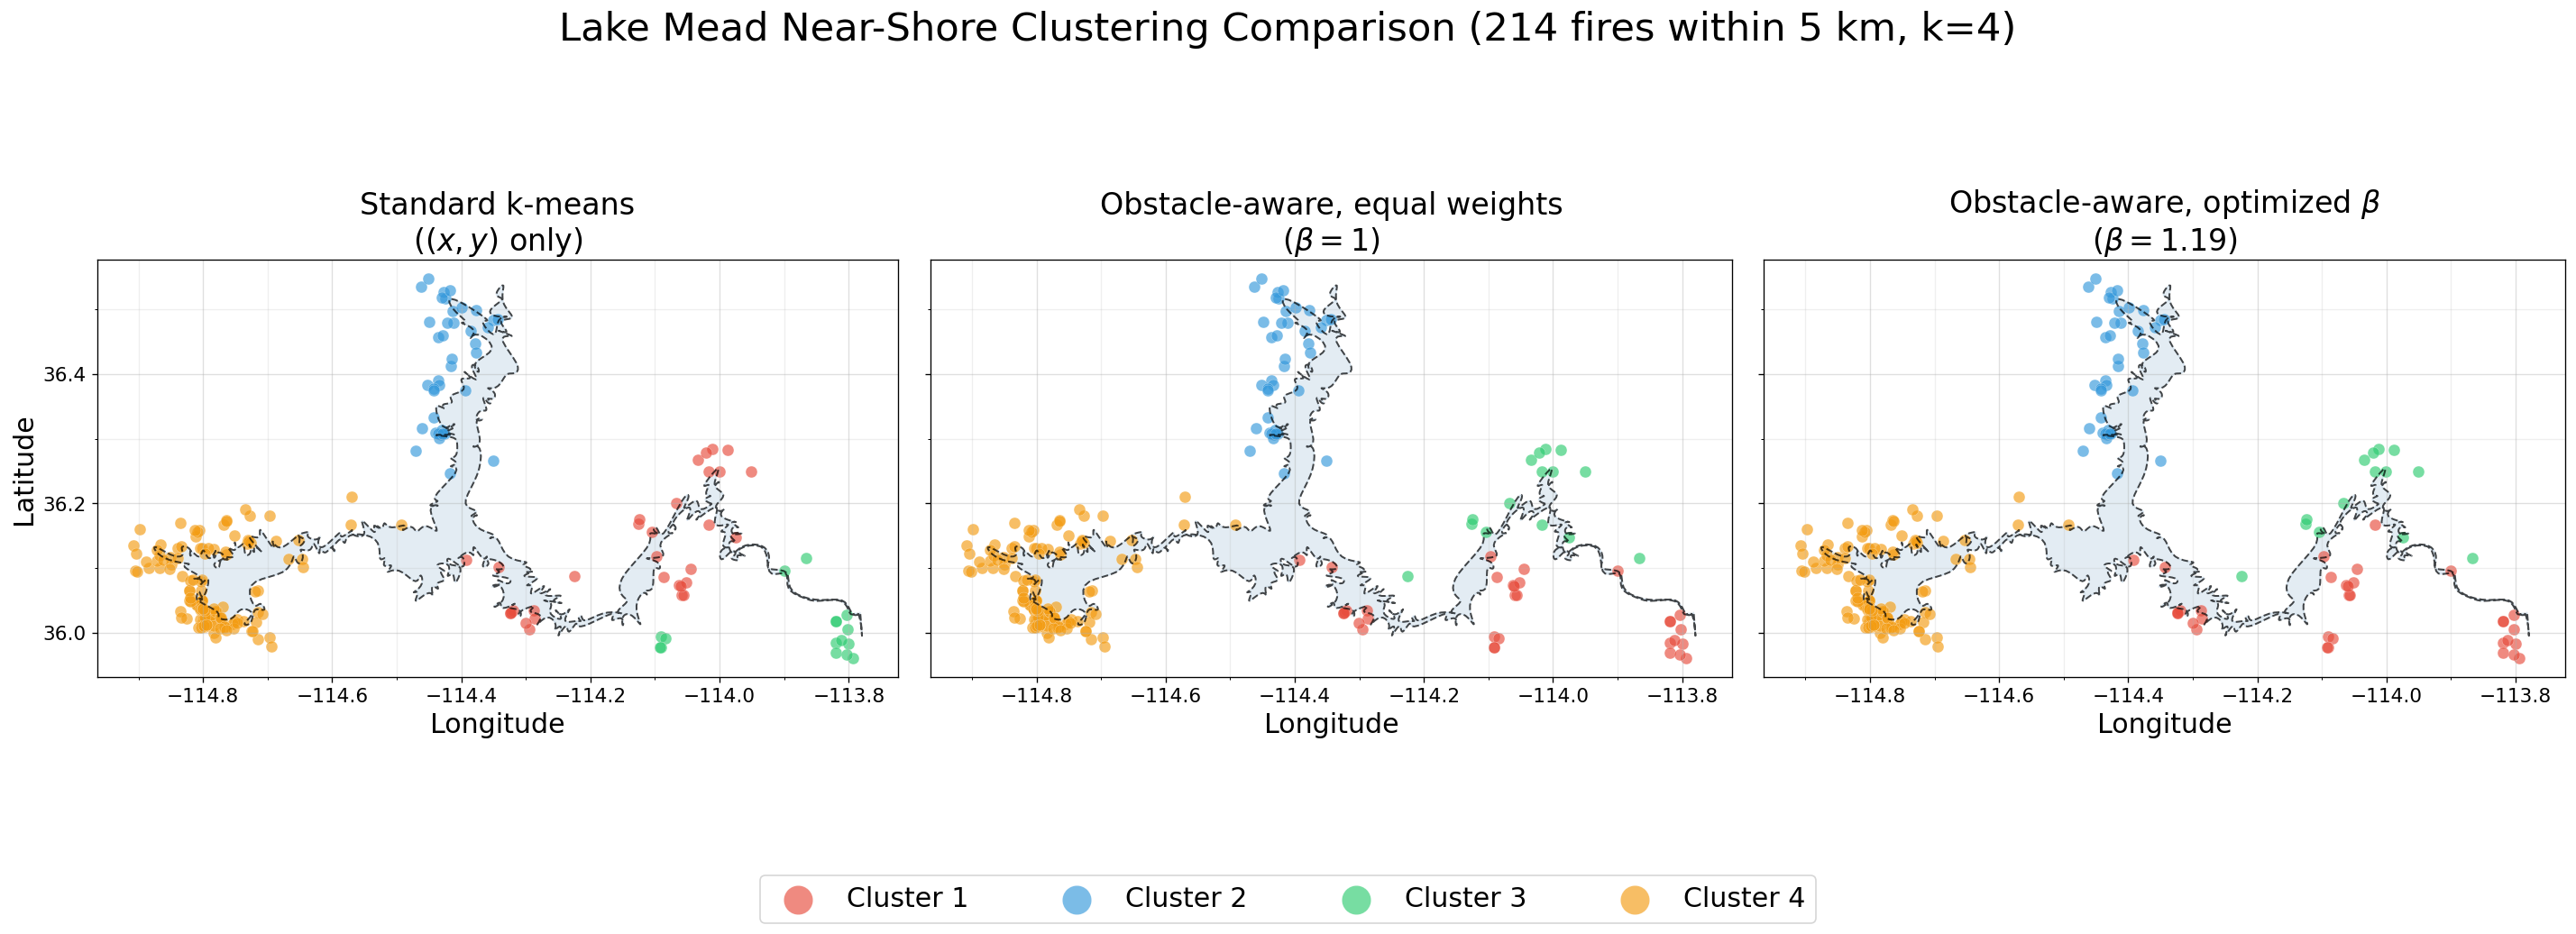

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharex=True, sharey=True)

for ax, labels, title in [
    (axes[0], labels_near_std_aligned, 'Standard k-means\n($(x, y)$ only)'),
    (axes[1], labels_near_eq_aligned,
     r'Obstacle-aware, equal weights' + '\n' + r'($\beta = 1$)'),
    (axes[2], labels_near_opt_aligned,
     r'Obstacle-aware, optimized $\beta$' + '\n' +
     rf'($\beta = {opt_beta_near:.2f}$)'),
]:
    # Boundary
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
            linewidth=1.2, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.15, color='steelblue')

    # Fires colored by cluster
    for i in range(k):
        mask = labels == i
        ax.scatter(fires_near['LONGITUDE'].values[mask],
                   fires_near['LATITUDE'].values[mask],
                   c=CLUSTER_COLORS[i], s=60, alpha=0.65,
                   label=f'Cluster {i+1}', edgecolors='white', linewidth=0.2)

    ax.set_title(title, fontsize=20)
    ax.set_xlabel('Longitude', fontsize=18)
    ax.set_aspect('equal')

    # Gridlines every 0.10 on both axes; labels only every 0.20
    ax.xaxis.set_major_locator(MultipleLocator(0.20))   # labeled
    ax.xaxis.set_minor_locator(MultipleLocator(0.10))   # gridline only
    ax.yaxis.set_major_locator(MultipleLocator(0.20))   # labeled
    ax.yaxis.set_minor_locator(MultipleLocator(0.10))   # gridline only
    ax.grid(which='major', alpha=0.4)
    ax.grid(which='minor', alpha=0.2)

    ax.tick_params(axis='both', which='major', labelsize=13)

axes[0].set_ylabel('Latitude', fontsize=18)

# Larger legend, pushed further below the panels
handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, leg_labels, loc='lower center', ncol=k,
           bbox_to_anchor=(0.5, -0.04), frameon=True, fontsize=18,
           markerscale=2.5, columnspacing=3.0, handletextpad=0.8)

fig.suptitle(
    f'Lake Mead Near-Shore Clustering Comparison '
    f'({n_near} fires within {threshold_km} km, k={k})',
    fontsize=26, y=1.03
)

# Reserve bottom room for the legend; pull panels close together
plt.tight_layout(rect=[0, 0.10, 1, 0.97])
plt.subplots_adjust(wspace=0.04)
plt.show()

### Comparison Statistics

Near the shore, the obstacle parameter clearly helps. Equal weights tightens the mean span by 9.1% over standard k-means, and the optimized $\beta$ reaches 19.0%. The improvement comes almost entirely from green Cluster 1, which is very loose under standard k-means (span 0.42): it reaches across the water rather than following one stretch of shore. The obstacle-aware versions pull it in to about 0.24. The other three clusters barely move, so this isn't a broad retightening, it's the shoreline parameter fixing the one cluster that standard k-means split across the lake.

In [36]:
# Recompute per-cluster spans from the aligned labels so the columns match
# the plot colors and are comparable across methods.
spans_near_std_aligned = [arc_length_span(s_near[labels_near_std_aligned == c]) for c in range(k)]
spans_near_eq_aligned  = [arc_length_span(s_near[labels_near_eq_aligned == c])  for c in range(k)]
spans_near_opt_aligned = [arc_length_span(s_near[labels_near_opt_aligned == c]) for c in range(k)]

near_methods = [
    ('Standard k-means', spans_near_std_aligned),
    ('OA, equal weights (β=1)', spans_near_eq_aligned),
    (f'OA, optimized (β={opt_beta_near:.2f})', spans_near_opt_aligned),
]

std_mean_near = np.mean(spans_near_std_aligned)

rows = []
for name, spans in near_methods:
    mean_span = np.mean(spans)
    # Percent change in span vs standard; negative span change = improvement,
    # so we report improvement as a positive percent (standard is the 0% baseline).
    pct = 100 * (std_mean_near - mean_span) / std_mean_near
    row = {'Method': name}
    for c in range(k):
        row[f'Cluster {c+1}'] = spans[c]
    row['Mean span'] = mean_span
    row['vs standard'] = pct
    rows.append(row)

near_comparison = pd.DataFrame(rows).set_index('Method')

# Format: spans to 4 decimals, percent with sign and 1 decimal
fmt = {f'Cluster {c+1}': '{:.4f}' for c in range(k)}
fmt['Mean span'] = '{:.4f}'
fmt['vs standard'] = '{:+.1f}%'

print(f'Lake Mead near-shore cluster spans comparison '
      f'({n_near} fires within {threshold_km} km of shore)')
near_comparison.style.format(fmt)

Lake Mead near-shore cluster spans comparison (214 fires within 5 km of shore)


,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Mean span,vs standard
Method,,,,,,
Standard k-means,0.4202,0.1864,0.1573,0.2062,0.2425,+0.0%
"OA, equal weights (β=1)",0.2358,0.1864,0.2532,0.2062,0.2204,+9.1%
"OA, optimized (β=1.19)",0.2358,0.1864,0.1572,0.2062,0.1964,+19.0%


## 16. Basin vs. Near-Shore Summary

The obstacle parameter helps at both scales on Lake Mead, but it helps more near the shore. Across the full basin, equal weights does nothing and the optimized $\beta$ tightens the mean span by 7.3%. Near the shore the gain is much larger: equal weights already improves span by 9.1%, and the optimized $\beta$ reaches 19.0%.

A likely reason is where the fires sit relative to the lake's arms. Across the whole basin, many fires are far from the water, where their position around the shoreline is only loosely tied to the arm structure, so $s$ has less of a role. The near-shore fires hug the arms directly, so the arc-length parameter has sharp, well-defined structure to work with, and tightening clusters along the shore makes a bigger difference.

In [38]:
# Combined basin + near-shore summary. Pulls means already computed.
std_mean_basin = np.mean(spans_basin_std)
std_mean_near = np.mean(spans_near_std)

summary_rows = [
    # scale,        method,                                  n_fires,    spans
    ('Basin',      'Standard k-means',                       len(fires), spans_basin_std),
    ('Basin',      'OA, equal weights (β=1)',                len(fires), spans_basin_eq),
    ('Basin',      f'OA, optimized (β={opt_beta_basin:.2f})', len(fires), spans_basin_opt),
    ('Near-shore', 'Standard k-means',                       n_near,     spans_near_std),
    ('Near-shore', 'OA, equal weights (β=1)',                n_near,     spans_near_eq),
    ('Near-shore', f'OA, optimized (β={opt_beta_near:.2f})',  n_near,     spans_near_opt),
]

rows = []
for scale, method, n_fires, spans in summary_rows:
    mean_span = np.mean(spans)
    # Improvement is measured against that scale's own standard k-means baseline.
    std_mean = std_mean_basin if scale == 'Basin' else std_mean_near
    pct = 100 * (std_mean - mean_span) / std_mean
    rows.append({
        'Scale': scale,
        'Method': method,
        'Fires': n_fires,
        'Mean span': mean_span,
        'Span improvement': pct,
    })

summary = pd.DataFrame(rows).set_index(['Scale', 'Method'])

fmt = {
    'Fires': '{:d}',
    'Mean span': '{:.4f}',
    'Span improvement': '{:+.1f}%',
}

print('Lake Mead: basin vs. near-shore summary')
summary.style.format(fmt)

Lake Mead: basin vs. near-shore summary


## 17. Cluster Attribute Composition (Near-Shore)

The near-shore subset is where the obstacle parameter made the biggest difference, tightening the clusters by 19%. Therefore it's a good place to explore whether the resulting clusters happen to differ in their fire attributes, even though the clustering only ever used location. We show the attribute breakdown for both the standard and optimized clusterings, then test whether any of the differences are statistically meaningful.

The tables below break down each cluster's size, the split between human-caused and natural fires, and the typical and average fire size, first for standard k-means and then for the optimized obstacle-aware clustering.

In [ ]:
def cluster_composition(labels, fires_subset):
    """Per-cluster size, cause split, and fire-size summary for a labeling.
    Built from aligned labels, so cluster numbers match the plot colors."""
    rows = []
    for c in range(k):
        mask = labels == c
        sizes = fires_subset['FIRE_SIZE'].values[mask]
        human = fires_subset['cause_binary'].values[mask]   # 1 = human, 0 = natural
        rows.append({
            'Cluster': c + 1,
            'Fires': int(mask.sum()),
            '% human': 100 * human.mean(),
            '% natural': 100 * (1 - human.mean()),
            'Median size (ac)': np.median(sizes),
            'Mean size (ac)': sizes.mean(),
        })
    return pd.DataFrame(rows).set_index('Cluster')


fmt = {
    'Fires': '{:d}',
    '% human': '{:.1f}',
    '% natural': '{:.1f}',
    'Median size (ac)': '{:.2f}',
    'Mean size (ac)': '{:.2f}',
}

# Standard k-means composition table
print('Standard k-means:')
display(cluster_composition(labels_near_std_aligned, fires_near).style.format(fmt))

# Optimized obstacle-aware composition table
print(f'\nObstacle-aware, optimized (β={opt_beta_near:.2f}):')
display(cluster_composition(labels_near_opt_aligned, fires_near).style.format(fmt))

Standard k-means:


,Fires,% human,% natural,Median size (ac),Mean size (ac)
Cluster,,,,,
1,32,65.6,34.4,0.10,1.75
2,40,75.0,25.0,0.15,11.00
3,16,25.0,75.0,0.10,60.39
4,126,75.4,24.6,0.10,0.26



Obstacle-aware, optimized (β=1.19):


,Fires,% human,% natural,Median size (ac),Mean size (ac)
Cluster,,,,,
1,34,47.1,52.9,0.10,23.94
2,40,75.0,25.0,0.15,11.00
3,14,64.3,35.7,0.30,14.87
4,126,75.4,24.6,0.10,0.26


### Testing for Significant Differences

As in the Tahoe notebook, we test each attribute across the four clusters with the Kruskal-Wallis test, following up significant results with Dunn's test and a Bonferroni correction. We report the fraction of cluster pairs that differ significantly in fire size, and in cause, for both the standard and optimized clusterings.

We find near-shore clusters do differ in their attributes. Under standard k-means, half the cluster pairs differ significantly (3 of 6 in fire size, 3 of 6 in cause). Since the clustering only used location, this means fire behavior around Lake Mead isn't spread evenly: some stretches of shore see larger fires, or more human-caused ones, than others.

Interestingly, the optimized obstacle-aware clustering shows slightly less attribute separation, not more (an overall fraction of 0.33 versus 0.50). Tightening the clusters along the shoreline grouped fires by geography in a way that cuts a little across the attribute patterns, so the obstacle-aware clusters are more coherent along the shore but less distinct in fire size and cause. The two goals don't perfectly align, which is expected.

In [42]:
# Attributes live in columns 3 (fire size, log-scaled) and 4 (cause binary).
attr_indices = [3, 4]
attr_labels = {3: 'Fire size', 4: 'Cause'}

def attr_fractions(labels, method_name):
    sigma, details = attribute_separation(X_near, labels, k, attr_indices)
    print(f'{method_name}:')
    n_pairs = k * (k - 1) // 2
    for idx in attr_indices:
        sig_pairs = details[idx]['pairwise_significant']
        print(f'  {attr_labels[idx]:10s}: {len(sig_pairs)}/{n_pairs} '
              f'pairs differ significantly')
    print(f'  Overall significant fraction: {sigma:.2f}\n')
    return sigma

_ = attr_fractions(labels_near_std_aligned, 'Standard k-means')
_ = attr_fractions(labels_near_opt_aligned, f'Obstacle-aware, optimized (β={opt_beta_near:.2f})')

Standard k-means:
  Fire size : 3/6 pairs differ significantly
  Cause     : 3/6 pairs differ significantly
  Overall significant fraction: 0.50

Obstacle-aware, optimized (β=1.19):
  Fire size : 3/6 pairs differ significantly
  Cause     : 1/6 pairs differ significantly
  Overall significant fraction: 0.33



## 18. Comparing Mead and Tahoe

Side by side, the two lakes show that the obstacle parameter's value depends on the shape of the lake and where the fires sit relative to it.

At the basin scale the two are similar: obstacle-aware clustering tightens the span by about 7 to 8% on both. The difference shows up near the shore. On Tahoe the near-shore obstacle parameter does nothing (it recovers plain k-means), while on Mead it gives the largest improvement of all, 19%.

Geometry is one likely contributer to this. Tahoe is a single compact, roughly oval basin, so near its shore a fire's position around the lake is almost completely fixed by its $(x, y)$ location, and the arc-length parameter $s$ has nothing to add. Mead is long and narrow with several arms, so two fires on different arms can be close in straight-line distance but far apart along the shoreline. There $s$ carries real information the coordinates don't, and it contributes most exactly where the fires hug the arms, near the shore. In general, $s$ helps when the lake's shape makes distance along the shore differ from straight-line distance, which a compact lake rarely does and a long, multi-arm lake does constantly.

One caveat: the two near-shore subsets are paired by the fraction of fires they keep (about a quarter of each lake), not by distance. Tahoe uses a 1 km threshold and Mead needs 5 km for a comparable share. Mead's near-shore fires therefore sit farther from the water on average, and some of the difference could come from that rather than shape alone, a confound this analysis can't fully separate out.

In [46]:
# Tahoe headline results, from Notebook 02 (hardcoded for the cross-lake
# comparison so this notebook doesn't depend on re-running Tahoe's analysis).
# Each entry: (n_fires, standard span, optimized span, optimized beta).
tahoe = {
    'Basin':      {'n': 1068, 'std': 0.2650, 'opt': 0.2435, 'beta': 1.99},
    'Near-shore': {'n':  296, 'std': 0.2246, 'opt': 0.2246, 'beta': 0.86},
}

# Mead results, computed in this notebook.
mead = {
    'Basin':      {'n': len(fires), 'std': np.mean(spans_basin_std),
                   'opt': np.mean(spans_basin_opt), 'beta': opt_beta_basin},
    'Near-shore': {'n': n_near, 'std': np.mean(spans_near_std),
                   'opt': np.mean(spans_near_opt), 'beta': opt_beta_near},
}

rows = []
for lake, results in [('Lake Tahoe', tahoe), ('Lake Mead', mead)]:
    for scale in ['Basin', 'Near-shore']:
        r = results[scale]
        pct = 100 * (r['std'] - r['opt']) / r['std']
        rows.append({
            'Lake': lake,
            'Scale': scale,
            'Fires': int(r['n']),
            'Optimized span': r['opt'],
            'Improvement': pct,
        })

cross_lake = pd.DataFrame(rows).set_index(['Lake', 'Scale'])

fmt = {
    'Fires': '{:d}',
    'Optimized span': '{:.4f}',
    'Improvement': '{:+.1f}%',
}

print('Cross-lake comparison: span improvement from obstacle-aware clustering')
cross_lake.style.format(fmt)

Cross-lake comparison: span improvement from obstacle-aware clustering


## 19. Saving Outputs

Save results for use in Notebook 04 and ArcGIS dashboard.

### 20.1 Fires with All Cluster Assignments

In [51]:
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

# Write all cluster labels to the fires DataFrame 
fires['cluster_basin_std'] = labels_basin_std_aligned
fires['cluster_basin_eq']  = labels_basin_eq_aligned
fires['cluster_basin_opt'] = labels_basin_opt_aligned

# Near-shore labels: NaN for fires outside the subset
fires['cluster_near_std'] = np.nan
fires['cluster_near_eq']  = np.nan
fires['cluster_near_opt'] = np.nan
fires.loc[near_mask, 'cluster_near_std'] = labels_near_std_aligned
fires.loc[near_mask, 'cluster_near_eq']  = labels_near_eq_aligned
fires.loc[near_mask, 'cluster_near_opt'] = labels_near_opt_aligned

fires_path = processed_dir / 'mead_fires_clustered.csv'   
fires.to_csv(fires_path, index=False)

print(f'Saved {len(fires)} clustered fires to:')
print(f'  {fires_path}')

Saved 844 clustered fires to:
  ..\data\processed\mead_fires_clustered.csv


### 20.2 Cluster Summary

Per-cluster statistics for the basin-scale standard and optimized clusterings. The dashboard uses this for indicators that display cluster-level numbers (mean fire size per cluster, percent human-caused, etc.).

In [53]:
# Convert the spline's arc length (in degrees) to km. At Lake Mead's latitude
# (~36 N), 1 deg latitude ~= 111 km and 1 deg longitude ~= 90 km; the spline
# spans both directions, so we use their average. 
deg_to_km = (111 + 90) / 2  # ~100.5 km/deg
perimeter_km = boundary.total_arc_length() * deg_to_km

print(f'Lake Mead shoreline perimeter: ~{perimeter_km:.0f} km')


# Per-cluster summary for the near-shore subset, for both clusterings
summary_rows = []
for method_name, labels in [('std', labels_near_std_aligned),
                            ('oa_opt', labels_near_opt_aligned)]:
    for cluster_id in range(k):
        sub = fires_near[labels == cluster_id]
        sub_s = s_near[labels == cluster_id]
        span = arc_length_span(sub_s)
        summary_rows.append({
            'method': method_name,
            'cluster_id': cluster_id,
            'cluster_label': cluster_id + 1,
            'cluster_color': CLUSTER_COLORS[cluster_id],
            'n_fires': len(sub),
            'mean_fire_size': sub['FIRE_SIZE'].mean(),
            'median_fire_size': sub['FIRE_SIZE'].median(),
            'pct_human': 100 * (sub['cause_binary'] == 1).mean(),
            'pct_natural': 100 * (sub['cause_binary'] == 0).mean(),
            'cluster_span': span,
            'cluster_span_km': round(span * perimeter_km, 0),
        })

cluster_summary = pd.DataFrame(summary_rows)
cluster_summary_path = processed_dir / 'mead_cluster_summary.csv'
cluster_summary.to_csv(cluster_summary_path, index=False)

print(f'\nSaved near-shore cluster summary to:')
print(f'  {cluster_summary_path}')

Lake Mead shoreline perimeter: ~690 km

Saved near-shore cluster summary to:
  ..\data\processed\mead_cluster_summary.csv


### 20.3 Global Metrics

One-row CSV with the headline metrics. Used by the dashboard for top-level indicators.

In [55]:
# Recompute the optimized improvement here, since the comparison table cell
# no longer defines it as a standalone variable.
span_pct_opt_near = 100 * (np.mean(spans_near_std) - np.mean(spans_near_opt)) / np.mean(spans_near_std)

global_metrics = pd.DataFrame([{
    'lake': 'Mead',
    'subset': 'near_shore',
    'threshold_km': threshold_km,
    'total_fires': n_near,
    'year_min': int(fires_near['FIRE_YEAR'].min()),
    'year_max': int(fires_near['FIRE_YEAR'].max()),
    'k': k,
    'opt_beta': opt_beta_near,
    'span_std': np.mean(spans_near_std),
    'span_oa_opt': np.mean(spans_near_opt),
    'span_improvement_pct': span_pct_opt_near,
    'perimeter_km': round(perimeter_km, 0),
    'mean_span_std_km': round(np.mean(spans_near_std) * perimeter_km, 0),
    'mean_span_oa_opt_km': round(np.mean(spans_near_opt) * perimeter_km, 0),
}])

global_metrics_path = processed_dir / 'mead_global_metrics.csv'
global_metrics.to_csv(global_metrics_path, index=False)

print(f'Saved global metrics to:')
print(f'  {global_metrics_path}')
print()
print(global_metrics.to_string(index=False))

Saved global metrics to:
  ..\data\processed\mead_global_metrics.csv

lake     subset  threshold_km  total_fires  year_min  year_max  k  opt_beta  span_std  span_oa_opt  span_improvement_pct  perimeter_km  mean_span_std_km  mean_span_oa_opt_km
Mead near_shore             5          214      1992      2020  4  1.193103  0.242527     0.196415             19.013494         690.0             167.0                136.0


## 21. Summary

This notebook applied obstacle-aware k-means to wildfires around Lake Mead and compared the results to Lake Tahoe.

- **Basin scale**: the optimized obstacle-aware clustering tightened the mean span by 7.3% over standard k-means, close to Tahoe's 8.1%. At this scale the two lakes behave similarly.
- **Near-shore scale**: this is where they diverge. Mead's near-shore clustering improved by 19.0%, the largest gain in either notebook, while Tahoe's near-shore showed no improvement at all.

Shape is likely driving the different results between the two lakes. Mead is long and narrow with several arms, so two fires on different arms can sit close in straight-line distance but far apart along the shoreline, and $s$ captures that, most of all near the shore where the fires hug the arms. Tahoe is compact and roughly oval, so a fire's position around the lake is already implied by its coordinates and $s$ has little to add. The obstacle parameter helps most when a lake's shape makes distance along the shore differ sharply from straight-line distance.

We also checked whether the near-shore clusters happened to differ in fire size or cause. Unlike Tahoe, Mead's showed real attribute differences, although improved span compactness did not correspond to improved attribute separation. 

The Lake Mead near-shore results are the focus of the interactive dashboard built in Notebook 04, which maps the standard and obstacle-aware clusterings side by side and lets you explore how the 214 near-shore fires regroup along the shoreline.

**Where this could go next.** Future directions could include: testing a range of near-shore thresholds to separate the effect of lake shape from how close the fires sit to the water; running the method on more lakes across a spectrum of shapes to generalize the two-lake contrast; and extending it beyond lakes entirely, to other physical obstacles and other kinds of spatial data where a boundary distorts how points should be grouped.